# Efek Buffer Termal Lahan Basah: Heat Diffusion, Data Dummy, NN, dan PINN

Notebook ini membuat alur lengkap untuk:

1. Menurunkan persamaan heat diffusion dari Hukum I Termodinamika dan Hukum Fourier.
2. Menyesuaikan persamaan tersebut untuk efek buffer termal lahan basah.
3. Membuat data dummy realistis untuk 3 hari observasi, dari 5 AM sampai 7 PM, dengan cuaca cerah.
4. Melatih Neural Network biasa dan Physics-Informed Neural Network.
5. Membandingkan akurasi NN dan PINN pada ekstrapolasi 3 hari berikutnya.
6. Membuat plot 2D dan GIF animasi suhu.

Catatan penting: data pada notebook ini adalah data sintetis berbasis teori fisika dan kisaran nilai dari literatur. Hari 1 sampai 3 diperlakukan sebagai data observasi untuk training. Hari 4 sampai 6 dibuat sebagai ground truth sintetis yang disembunyikan dari training dan hanya dipakai untuk evaluasi ekstrapolasi.

## 1. Rujukan ilmiah yang dipakai

Rujukan berikut dipakai untuk menentukan struktur model dan kisaran parameter, bukan untuk mengklaim bahwa data dummy ini adalah data pengukuran lapangan nyata.

- Fourier heat conduction dan heat diffusion: dari konservasi energi, fluks panas konduktif mengikuti `q = -k grad(T)`, sehingga `rho c_p dT/dt = div(k grad(T)) + Q`.
- FAO Irrigation and Drainage Paper 56 menjelaskan Penman-Monteith sebagai pendekatan yang menggabungkan parameter pertukaran energi dan fluks panas laten evapotranspirasi. Rujukan: https://www.fao.org/4/X0490E/x0490e06.htm
- Studi Xixi Wetland, Hangzhou, memakai pengamatan 3 hari cuaca cerah, 8 AM sampai 6 PM, dan menemukan lahan basah berperan dalam regulasi mikroklimat, antara lain karena evapotranspirasi dan heat storage. Rujukan: https://www.mdpi.com/2071-1050/8/9/885
- Studi termal tanah gambut melaporkan nilai contoh konduktivitas termal, kapasitas panas volumetrik, dan thermal diffusivity gambut yang relevan untuk lapisan basah/jenuh air. Rujukan PDF: https://peatlands.org/assets/uploads/2019/06/ipc2008p323-326-gnatowski-thermal-diffusivity-of-peat-soil.pdf
- Studi-studi urban wetland cooling effect umumnya mengaitkan pendinginan dengan air, vegetasi, evapotranspirasi, bentuk patch, dan konteks lahan sekitar. Rujukan contoh: https://www.sciencedirect.com/science/article/pii/S0169204621000889

Asumsi model dalam notebook ini dibuat konservatif untuk simulasi demonstrasi. Untuk riset final, parameter sebaiknya dikalibrasi dengan sensor lokal: suhu udara, suhu permukaan, kelembapan, radiasi matahari, angin, water table, jenis tanah/gambut, vegetasi, dan geometri lahan.

### Angka literatur yang memandu data dummy

| Komponen | Nilai/keterangan dari literatur | Pemakaian di notebook |
|---|---:|---|
| Durasi observasi lahan basah | Studi Xixi memakai 3 hari cuaca cerah per musim, 8 AM sampai 6 PM, perekaman per jam | Notebook memakai 3 hari training, cuaca cerah, diperluas menjadi 5 AM sampai 7 PM dan sampling 15 menit |
| Suhu musim panas Xixi | Rata-rata semua titik sekitar 36.4 degC, puncak harian sekitar 1 PM sampai 2 PM, rentang harian musim panas sekitar 6.3 degC | Fungsi cuaca dibuat berpuncak sekitar 2 PM; suhu sintetis berada pada rentang realistis untuk proksi suhu dekat permukaan/skin temperature |
| Peran buffer wetland | Xixi menunjukkan area protected wetland umumnya lebih dingin dan lebih stabil daripada former wetland | Data dummy menghasilkan area basah lebih dingin daripada area kering, terutama saat radiasi tinggi |
| Fraksi air lahan basah | Xixi Wetland Park dilaporkan memiliki badan air sekitar 70% | Domain dummy adalah wetland plus area sekitar; fraksi air rata-rata lebih rendah, tetapi indeks wetland `water + 0.7 vegetation` dibuat dominan |
| Termal gambut | Contoh peat surface layer: lambda sekitar 0.317 W/m/K, Cv sekitar 2.96e6 J/m3/K, KT sekitar 1.85 sampai 6.50 cm2/h | Digunakan sebagai pembanding bahwa konduksi tanah murni kecil; `alpha_eff` notebook lebih besar karena mewakili difusi efektif mikroklimat lateral |
| Evapotranspirasi | FAO Penman-Monteith menggabungkan neraca energi, resistansi aerodinamik/permukaan, dan fluks panas laten | Di notebook, efek ini diringkas sebagai komponen `evap_cooling` pada `T_eq` |

Karena tujuan notebook adalah demonstrasi PINN/NN, model dibuat cukup sederhana agar bisa dijalankan cepat. Jika dipakai untuk publikasi atau desain lapangan, ganti forcing dan parameter dengan data sensor lokal.

## 2. Turunan persamaan dari Hukum I Termodinamika dan Hukum Fourier

Ambil elemen kontrol kecil pada lahan basah dengan volume $dV = dx\, dy\, dz$. Hukum I Termodinamika untuk sistem tanpa kerja mekanik makroskopik menyatakan:

$$\text{laju perubahan energi internal} = \text{panas masuk bersih} + \text{sumber panas internal}$$

Energi internal termal per volume dapat ditulis:

$$u = \rho\, c_p\, T$$

dengan:

- $\rho$ = densitas efektif medium basah, kg/m³.
- $c_p$ = panas jenis efektif, J/kg/K.
- $T$ = suhu, °C atau K. Untuk beda suhu, °C dan K ekuivalen.

Untuk sebuah volume kontrol:

$$\frac{d}{dt}\int_V \rho\, c_p\, T\, dV = -\oint_{\partial V} \mathbf{q} \cdot \hat{n}\, dA + \int_V Q\, dV$$

Gunakan Teorema Divergensi:

$$\rho\, c_p \frac{\partial T}{\partial t} = -\nabla \cdot \mathbf{q} + Q$$

Hukum Fourier untuk konduksi panas:

$$\mathbf{q} = -k\, \nabla T$$

dengan $k$ = konduktivitas termal, W/m/K. Substitusi ke konservasi energi:

$$\rho\, c_p \frac{\partial T}{\partial t} = \nabla \cdot \left(k\, \nabla T\right) + Q$$

Jika $k$ konstan:

$$\frac{\partial T}{\partial t} = \alpha\, \nabla^2 T + \frac{Q}{\rho\, c_p}, \qquad \alpha = \frac{k}{\rho\, c_p}$$

Ini adalah persamaan *heat diffusion*.

Untuk peta horizontal lahan basah, kita sering memakai lapisan aktif tipis dengan kedalaman efektif $H$. Kapasitas panas areal:

$$C_A = \rho\, c_p\, H \qquad [\text{J/m}^2\text{/K}]$$

Maka bentuk 2D yang dipakai dalam notebook ini:

$$\frac{\partial T}{\partial t} = \alpha_{\text{eff}} \left(\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2}\right) + \frac{T_{\text{eq}}(x,y,t) - T}{\tau(x,y)}$$

Komponen $\dfrac{T_{\text{eq}} - T}{\tau}$ adalah bentuk linear dari neraca energi permukaan:

$$C_A \frac{\partial T}{\partial t} = R_n - LE - H_{\text{sensible}} - G + \text{konduksi/adveksi lateral}$$

Interpretasinya:

- $R_n$ menaikkan suhu melalui radiasi bersih.
- $LE$ menurunkan suhu melalui evapotranspirasi dan panas laten.
- $H_{\text{sensible}}$ menukar panas dengan udara sekitar.
- $G$ menyimpan/melepas panas ke tanah/air.
- $\tau$ besar berarti medium lambat berubah suhu. Air dan tanah jenuh biasanya punya $\tau$ lebih besar daripada permukaan kering/keras.
- $\alpha_{\text{eff}}$ di sini adalah difusivitas efektif lateral. Untuk tanah murni nilainya kecil, tetapi pada peta lahan basah skala puluhan meter ia juga mewakili pencampuran udara dekat permukaan, turbulensi, dan konektivitas air dangkal.

## 3. Teori fisika pendukung efek buffer lahan basah

Efek buffer termal lahan basah muncul dari beberapa mekanisme fisika yang bekerja bersamaan:

1. Kapasitas panas air tinggi. Air menyimpan energi lebih besar per kenaikan suhu dibanding permukaan kering, sehingga suhu naik lebih lambat pada siang hari dan turun lebih lambat pada sore hari.
2. Panas laten evapotranspirasi. Energi radiasi dipakai untuk menguapkan air, bukan seluruhnya untuk menaikkan suhu permukaan. Ini membuat area basah dan bervegetasi lebih dingin saat radiasi tinggi.
3. Konduksi dan difusi panas di tanah/air. Gradien suhu diratakan melalui fluks panas `q = -k grad(T)`.
4. Penyimpanan panas tanah jenuh/gambut. Tanah basah memiliki kapasitas panas volumetrik lebih tinggi daripada tanah kering karena fraksi air tinggi.
5. Naungan dan struktur vegetasi. Kanopi mengurangi radiasi gelombang pendek yang mencapai permukaan, sekaligus meningkatkan turbulensi kecil.
6. Albedo dan emisivitas. Permukaan air, vegetasi, tanah basah, dan beton menyerap serta memancarkan energi dengan cara berbeda.
7. Adveksi dan pencampuran udara. Patch basah yang lebih dingin dapat memengaruhi area sekitar melalui aliran udara dekat permukaan, terutama bila angin lemah sampai sedang.
8. Geometri patch. Luas, bentuk, rasio tepi, dan konektivitas air/vegetasi mengatur seberapa jauh pendinginan menyebar.

Notebook ini merangkum mekanisme tersebut dalam parameter yang mudah diganti: fraksi air, vegetasi, permukaan kering, `alpha_eff`, `tau`, respons radiasi, dan pendinginan evapotranspirasi.

## 4. Sel konfigurasi utama

Ubah nilai pada sel ini untuk menyesuaikan skenario. Parameter paling penting:

- `length_x_m`, `length_y_m`: ukuran domain lahan.
- `nx`, `ny`: resolusi grid. Naikkan untuk peta lebih halus, tetapi training lebih lama.
- `alpha_eff_m2_s`: difusivitas efektif lateral.
- `obs_noise_C`: noise sensor sintetis.
- `nn_epochs`, `pinn_epochs`: jumlah epoch training.
- `pde_weight`: bobot residual fisika pada PINN.
- Fungsi `spatial_cover_numpy/torch`: bentuk patch air, vegetasi, dan area kering.
- Fungsi `weather_forcing_numpy/torch`: cuaca cerah per jam.

In [79]:
CONFIG = {
    "domain": {
        "length_x_m": 120.0,
        "length_y_m": 80.0,
        "nx": 30,
        "ny": 20,
    },
    "time": {
        "start_hour": 5.0,
        "end_hour": 19.0,
        "dt_minutes": 5,
        "sample_minutes": 15,
        "train_days": 3,
        "forecast_days": 3,
    },
    "physics": {
        "alpha_eff_m2_s": 0.010,
        "obs_noise_C": 0.12,
        "water_tau_h": 5.0,
        "vegetation_tau_h": 3.4,
        "impervious_tau_h": 1.35,
        "max_clear_sky_solar_W_m2": 780.0,
    },
    "training": {
        "random_seed": 42,
        "nn_epochs": 600,
        "pinn_epochs": 600,
        "batch_size_data": 2048,
        "batch_size_collocation": 2048,
        "learning_rate": 1.0e-3,
        "pde_weight": 0.25,
        "residual_scale_C_per_h": 2.0,
        "hidden_width": 64,
        "hidden_depth": 4,
    },
    "outputs_dir": "outputs",
    "sample_dir": "sample",
}

In [80]:
from pathlib import Path
import math
import random
import time
import warnings

import imageio.v2 as imageio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore", category=UserWarning)

seed = CONFIG["training"]["random_seed"]
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUTS = Path(CONFIG["outputs_dir"])
SAMPLE = Path(CONFIG["sample_dir"])
OUTPUTS.mkdir(exist_ok=True)
SAMPLE.mkdir(exist_ok=True)

print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 3050


## 5. Domain spasial dan fraksi penutup lahan

Domain dibuat sebagai lahan 120 m x 80 m. Setiap titik grid memiliki tiga fraksi penutup:

- `water_frac`: badan air atau tanah sangat jenuh.
- `vegetation_frac`: vegetasi lahan basah.
- `impervious_frac`: area kering/terbuka/keras di sekitar patch.

Fraksi dibuat halus supaya cocok untuk PINN dan dapat diturunkan terhadap `x` dan `y`.

In [81]:
DOMAIN = CONFIG["domain"]
TIME = CONFIG["time"]
PHYS = CONFIG["physics"]

Lx = DOMAIN["length_x_m"]
Ly = DOMAIN["length_y_m"]
nx = DOMAIN["nx"]
ny = DOMAIN["ny"]

x_coords = np.linspace(0.0, Lx, nx)
y_coords = np.linspace(0.0, Ly, ny)
X, Y = np.meshgrid(x_coords, y_coords)
dx = x_coords[1] - x_coords[0]
dy = y_coords[1] - y_coords[0]

start_hour = TIME["start_hour"]
end_hour = TIME["end_hour"]
daylight_hours = end_hour - start_hour
dt_h = TIME["dt_minutes"] / 60.0
nsteps = int(round(daylight_hours * 60 / TIME["dt_minutes"]))
sample_every = int(round(TIME["sample_minutes"] / TIME["dt_minutes"]))
sample_steps = np.array([s for s in range(nsteps + 1) if s % sample_every == 0], dtype=int)
sample_hours = start_hour + sample_steps * dt_h

num_days = TIME["train_days"] + TIME["forecast_days"]
train_days = TIME["train_days"]
forecast_days = TIME["forecast_days"]
all_days = np.arange(1, num_days + 1)
future_days = np.arange(train_days + 1, num_days + 1)

print(f"Grid: {ny} x {nx} = {nx * ny} titik")
print(f"dx={dx:.2f} m, dy={dy:.2f} m")
print(f"Sample per day: {len(sample_hours)} titik waktu, dari {sample_hours[0]:.2f} sampai {sample_hours[-1]:.2f}")

Grid: 20 x 30 = 600 titik
dx=4.14 m, dy=4.21 m
Sample per day: 57 titik waktu, dari 5.00 sampai 19.00


In [82]:
def spatial_cover_numpy(x_m, y_m):
    '''Fraksi water, vegetation, impervious pada koordinat numpy.'''
    w1 = np.exp(-(((x_m - 50.0) / 27.0) ** 2 + ((y_m - 45.0) / 18.0) ** 2))
    w2 = 0.75 * np.exp(-(((x_m - 76.0) / 18.0) ** 2 + ((y_m - 29.0) / 13.0) ** 2))
    river = 1.2 * np.exp(-((y_m - (23.0 + 7.0 * np.sin(2.0 * np.pi * x_m / Lx))) ** 2) / (2.0 * 4.5 ** 2))
    water_raw = 2.8 * (w1 + w2) + river

    wet_influence = np.exp(-(((x_m - 58.0) / 42.0) ** 2 + ((y_m - 42.0) / 32.0) ** 2))
    forest_1 = 0.8 * np.exp(-(((x_m - 24.0) / 20.0) ** 2 + ((y_m - 63.0) / 14.0) ** 2))
    forest_2 = 0.7 * np.exp(-(((x_m - 96.0) / 18.0) ** 2 + ((y_m - 20.0) / 12.0) ** 2))
    vegetation_raw = 0.38 + 0.7 * wet_influence + forest_1 + forest_2

    hot_1 = 0.75 * np.exp(-(((x_m - 106.0) / 13.0) ** 2 + ((y_m - 62.0) / 10.0) ** 2))
    hot_2 = 0.45 * np.exp(-(((x_m - 22.0) / 12.0) ** 2 + ((y_m - 12.0) / 9.0) ** 2))
    impervious_raw = 0.30 + hot_1 + hot_2

    total = water_raw + vegetation_raw + impervious_raw
    return water_raw / total, vegetation_raw / total, impervious_raw / total


def spatial_cover_torch(x_m, y_m):
    '''Versi torch yang differentiable untuk PINN.'''
    w1 = torch.exp(-(((x_m - 50.0) / 27.0) ** 2 + ((y_m - 45.0) / 18.0) ** 2))
    w2 = 0.75 * torch.exp(-(((x_m - 76.0) / 18.0) ** 2 + ((y_m - 29.0) / 13.0) ** 2))
    river = 1.2 * torch.exp(-((y_m - (23.0 + 7.0 * torch.sin(2.0 * math.pi * x_m / Lx))) ** 2) / (2.0 * 4.5 ** 2))
    water_raw = 2.8 * (w1 + w2) + river

    wet_influence = torch.exp(-(((x_m - 58.0) / 42.0) ** 2 + ((y_m - 42.0) / 32.0) ** 2))
    forest_1 = 0.8 * torch.exp(-(((x_m - 24.0) / 20.0) ** 2 + ((y_m - 63.0) / 14.0) ** 2))
    forest_2 = 0.7 * torch.exp(-(((x_m - 96.0) / 18.0) ** 2 + ((y_m - 20.0) / 12.0) ** 2))
    vegetation_raw = 0.38 + 0.7 * wet_influence + forest_1 + forest_2

    hot_1 = 0.75 * torch.exp(-(((x_m - 106.0) / 13.0) ** 2 + ((y_m - 62.0) / 10.0) ** 2))
    hot_2 = 0.45 * torch.exp(-(((x_m - 22.0) / 12.0) ** 2 + ((y_m - 12.0) / 9.0) ** 2))
    impervious_raw = 0.30 + hot_1 + hot_2

    total = water_raw + vegetation_raw + impervious_raw
    return water_raw / total, vegetation_raw / total, impervious_raw / total


WATER, VEGETATION, IMPERVIOUS = spatial_cover_numpy(X, Y)
TAU_HOURS = (
    PHYS["water_tau_h"] * WATER
    + PHYS["vegetation_tau_h"] * VEGETATION
    + PHYS["impervious_tau_h"] * IMPERVIOUS
)

cover_summary = pd.DataFrame(
    {
        "cover": ["water", "vegetation", "impervious", "wetland_index_water_plus_0.7veg"],
        "mean_fraction": [WATER.mean(), VEGETATION.mean(), IMPERVIOUS.mean(), (WATER + 0.7 * VEGETATION).mean()],
        "min_fraction": [WATER.min(), VEGETATION.min(), IMPERVIOUS.min(), (WATER + 0.7 * VEGETATION).min()],
        "max_fraction": [WATER.max(), VEGETATION.max(), IMPERVIOUS.max(), (WATER + 0.7 * VEGETATION).max()],
    }
)
cover_summary

,cover,mean_fraction,min_fraction,max_fraction
0,water,0.272551,0.000065,0.694240
1,vegetation,0.473299,0.228638,0.728870
2,impervious,0.254150,0.071012,0.671697
3,wetland_index_water_plus_0.7veg,0.603860,0.231927,0.854640


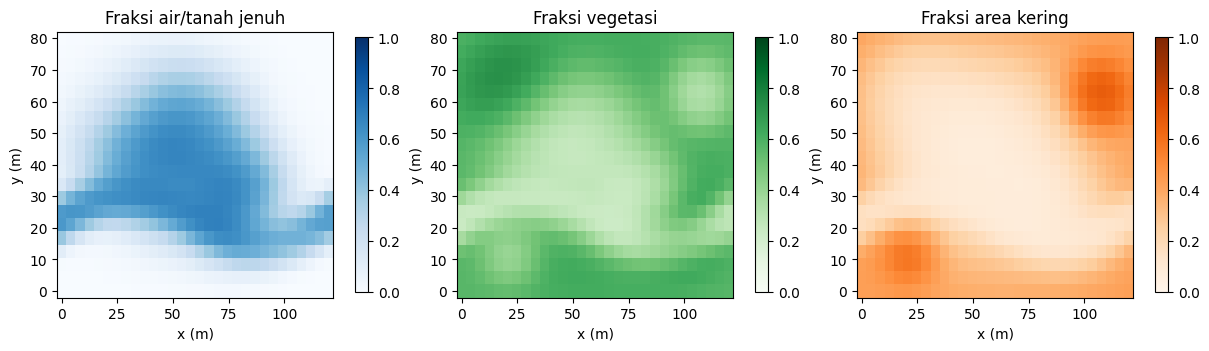

Saved: outputs\landcover_fraction_maps.png


In [83]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), constrained_layout=True)
for ax, arr, title, cmap in zip(
    axes,
    [WATER, VEGETATION, IMPERVIOUS],
    ["Fraksi air/tanah jenuh", "Fraksi vegetasi", "Fraksi area kering"],
    ["Blues", "Greens", "Oranges"],
):
    im = ax.pcolormesh(X, Y, arr, shading="auto", cmap=cmap, vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    fig.colorbar(im, ax=ax, fraction=0.046)

landcover_path = OUTPUTS / "landcover_fraction_maps.png"
fig.savefig(landcover_path, dpi=160)
plt.show()
print(f"Saved: {landcover_path}")

## 6. Cuaca cerah dan model neraca energi sederhana

Karena skenario diasumsikan cerah, radiasi matahari dibuat berbentuk kurva halus dari 5 AM sampai 7 PM, dengan maksimum sekitar tengah hari sampai awal siang. Suhu udara mengikuti siklus harian dengan puncak sekitar 2 PM.

Model suhu kesetimbangan lokal `T_eq` dibuat dari:

- pemanasan radiasi yang lebih besar di area kering,
- pendinginan evapotranspirasi yang lebih kuat di air dan vegetasi,
- titik panas lokal di area kering.

Persamaan yang diselesaikan:

```text
dT/dt = alpha_eff nabla^2 T + (T_eq - T)/tau
```

In [84]:
def weather_forcing_numpy(day, hour):
    '''Cuaca cerah sintetis. day boleh skalar, hour boleh skalar/array.'''
    hour = np.asarray(hour, dtype=float)
    phase = np.clip((hour - start_hour) / daylight_hours, 0.0, 1.0)
    solar_shape = np.sin(np.pi * phase) ** 1.15

    day_offset = 0.25 * np.sin(2.0 * np.pi * (day - 1.0) / 2.7) + 0.06 * (day - 1.0) / max(num_days - 1.0, 1.0)
    solar_scale = 1.0 + 0.03 * np.cos(2.0 * np.pi * (day - 1.0) / 3.2)

    temp_shape = np.sin(np.pi * np.clip((hour - 7.0) / 12.0, 0.0, 1.0))
    morning_cool = -0.9 * np.exp(-((hour - 5.0) / 2.2) ** 2)
    evening_warm = 0.6 * np.exp(-((hour - 18.0) / 2.5) ** 2)
    air_temp_C = 27.0 + 6.6 * temp_shape + morning_cool + evening_warm + day_offset

    solar_W_m2 = PHYS["max_clear_sky_solar_W_m2"] * solar_scale * solar_shape
    relative_humidity_pct = 83.0 - 27.0 * solar_shape + 2.0 * np.sin(2.0 * np.pi * (day - 1.0) / 4.0)
    wind_m_s = 1.1 + 0.25 * np.sin(2.0 * np.pi * phase + 0.8)
    return solar_W_m2, air_temp_C, relative_humidity_pct, wind_m_s


def weather_forcing_torch(t_hours):
    '''Forcing differentiable terhadap jam lokal di setiap hari.'''
    hour_of_day = start_hour + torch.remainder(t_hours, 24.0)
    phase = torch.clamp((hour_of_day - start_hour) / daylight_hours, 0.0, 1.0)
    solar_shape = torch.sin(math.pi * phase).clamp_min(0.0) ** 1.15

    day_number = torch.floor(t_hours / 24.0) + 1.0
    day_offset = 0.25 * torch.sin(2.0 * math.pi * (day_number - 1.0) / 2.7) + 0.06 * (day_number - 1.0) / max(num_days - 1.0, 1.0)
    solar_scale = 1.0 + 0.03 * torch.cos(2.0 * math.pi * (day_number - 1.0) / 3.2)

    temp_phase = torch.clamp((hour_of_day - 7.0) / 12.0, 0.0, 1.0)
    temp_shape = torch.sin(math.pi * temp_phase)
    morning_cool = -0.9 * torch.exp(-((hour_of_day - 5.0) / 2.2) ** 2)
    evening_warm = 0.6 * torch.exp(-((hour_of_day - 18.0) / 2.5) ** 2)
    air_temp_C = 27.0 + 6.6 * temp_shape + morning_cool + evening_warm + day_offset

    solar_W_m2 = PHYS["max_clear_sky_solar_W_m2"] * solar_scale * solar_shape
    relative_humidity_pct = 83.0 - 27.0 * solar_shape + 2.0 * torch.sin(2.0 * math.pi * (day_number - 1.0) / 4.0)
    wind_m_s = 1.1 + 0.25 * torch.sin(2.0 * math.pi * phase + 0.8)
    return solar_W_m2, air_temp_C, relative_humidity_pct, wind_m_s, day_number, hour_of_day, phase


def equilibrium_temperature_numpy(day, hour):
    solar_W_m2, air_temp_C, _, _ = weather_forcing_numpy(day, hour)
    solar_norm = solar_W_m2 / PHYS["max_clear_sky_solar_W_m2"]

    evap_cooling = (2.4 * WATER + 1.1 * VEGETATION) * solar_norm + 0.35 * WATER * (1.0 - solar_norm)
    radiative_heating = (7.3 * IMPERVIOUS + 2.8 * VEGETATION + 1.3 * WATER) * solar_norm
    hot_1 = 1.0 * np.exp(-(((X - 106.0) / 13.0) ** 2 + ((Y - 62.0) / 10.0) ** 2)) * solar_norm
    hot_2 = 0.55 * np.exp(-(((X - 22.0) / 12.0) ** 2 + ((Y - 12.0) / 9.0) ** 2)) * solar_norm
    return air_temp_C + radiative_heating - evap_cooling + hot_1 + hot_2


def equilibrium_temperature_torch(x_m, y_m, t_hours):
    water, vegetation, impervious = spatial_cover_torch(x_m, y_m)
    solar_W_m2, air_temp_C, _, _, _, _, _ = weather_forcing_torch(t_hours)
    solar_norm = solar_W_m2 / PHYS["max_clear_sky_solar_W_m2"]

    evap_cooling = (2.4 * water + 1.1 * vegetation) * solar_norm + 0.35 * water * (1.0 - solar_norm)
    radiative_heating = (7.3 * impervious + 2.8 * vegetation + 1.3 * water) * solar_norm
    hot_1 = 1.0 * torch.exp(-(((x_m - 106.0) / 13.0) ** 2 + ((y_m - 62.0) / 10.0) ** 2)) * solar_norm
    hot_2 = 0.55 * torch.exp(-(((x_m - 22.0) / 12.0) ** 2 + ((y_m - 12.0) / 9.0) ** 2)) * solar_norm
    return air_temp_C + radiative_heating - evap_cooling + hot_1 + hot_2


def tau_hours_torch(x_m, y_m):
    water, vegetation, impervious = spatial_cover_torch(x_m, y_m)
    return PHYS["water_tau_h"] * water + PHYS["vegetation_tau_h"] * vegetation + PHYS["impervious_tau_h"] * impervious

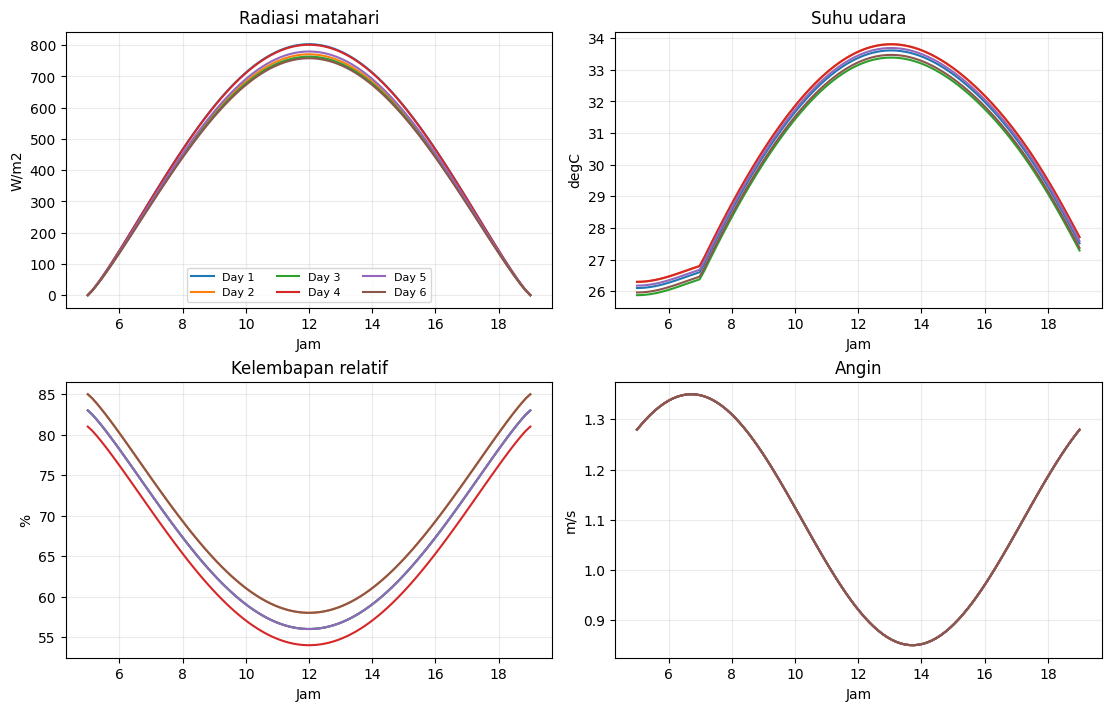

Saved: outputs\clear_sky_forcing.png


In [85]:
hours_plot = np.linspace(start_hour, end_hour, 100)
forcing_rows = []
for day in all_days:
    solar, air, rh, wind = weather_forcing_numpy(day, hours_plot)
    forcing_rows.append((day, solar, air, rh, wind))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for day, solar, air, rh, wind in forcing_rows:
    axes[0, 0].plot(hours_plot, solar, label=f"Day {day}")
    axes[0, 1].plot(hours_plot, air)
    axes[1, 0].plot(hours_plot, rh)
    axes[1, 1].plot(hours_plot, wind)

axes[0, 0].set_title("Radiasi matahari")
axes[0, 1].set_title("Suhu udara")
axes[1, 0].set_title("Kelembapan relatif")
axes[1, 1].set_title("Angin")
for ax in axes.ravel():
    ax.set_xlabel("Jam")
    ax.grid(True, alpha=0.25)
axes[0, 0].set_ylabel("W/m2")
axes[0, 1].set_ylabel("degC")
axes[1, 0].set_ylabel("%")
axes[1, 1].set_ylabel("m/s")
axes[0, 0].legend(ncol=3, fontsize=8)

forcing_path = OUTPUTS / "clear_sky_forcing.png"
fig.savefig(forcing_path, dpi=160)
plt.show()
print(f"Saved: {forcing_path}")

## 7. Simulator PDE untuk membuat ground truth sintetis

Ground truth sintetis dibuat dengan integrasi numerik eksplisit dari persamaan heat diffusion:

```text
T_new = T_old + dt * [alpha_eff * Laplacian(T_old) + (T_eq - T_old)/tau]
```

Syarat stabilitas eksplisit untuk difusi 2D kira-kira:

```text
alpha_eff * dt * (1/dx^2 + 1/dy^2) <= 0.5
```

Nilai ini dicek di bawah. Jika Anda menaikkan `alpha_eff_m2_s` atau memperbesar `dt_minutes`, cek stabilitas lagi. Bagian ini hanya dipakai sebagai pembangkit data dummy berbasis fisika; perbandingan model di notebook difokuskan pada NN dan PINN.

In [86]:
def initial_temperature_numpy(day):
    _, air_temp_C, _, _ = weather_forcing_numpy(day, start_hour)
    spatial_variation = 0.15 * np.sin(2.0 * np.pi * X / Lx) * np.cos(np.pi * Y / Ly)
    return air_temp_C - 0.25 * WATER + 0.25 * VEGETATION + 0.85 * IMPERVIOUS + spatial_variation


def laplacian_neumann(T):
    padded = np.pad(T, pad_width=1, mode="edge")
    d2x = (padded[1:-1, 2:] - 2.0 * T + padded[1:-1, :-2]) / dx ** 2
    d2y = (padded[2:, 1:-1] - 2.0 * T + padded[:-2, 1:-1]) / dy ** 2
    return d2x + d2y


def pde_step(T, day, hour, physics):
    alpha_h = physics["alpha_eff_m2_s"] * 3600.0
    tau_scale = physics.get("tau_scale", 1.0)
    rhs = alpha_h * laplacian_neumann(T) + (equilibrium_temperature_numpy(day, hour) - T) / (TAU_HOURS * tau_scale)
    return T + dt_h * rhs


def simulate_day(day, initial_field=None, physics=None):
    if physics is None:
        physics = {"alpha_eff_m2_s": PHYS["alpha_eff_m2_s"], "tau_scale": 1.0}
    T = initial_temperature_numpy(day) if initial_field is None else np.array(initial_field, dtype=float).copy()
    frames = []
    for step in range(nsteps + 1):
        if step % sample_every == 0:
            frames.append(T.copy())
        if step < nsteps:
            hour = start_hour + step * dt_h
            T = pde_step(T, day, hour, physics)
    return np.stack(frames, axis=0)


stability = PHYS["alpha_eff_m2_s"] * (TIME["dt_minutes"] * 60.0) * (1.0 / dx ** 2 + 1.0 / dy ** 2)
print(f"Stability number = {stability:.3f}; harus <= 0.5 untuk skema eksplisit sederhana.")

truth_fields = np.stack([simulate_day(day) for day in all_days], axis=0)
print("truth_fields shape:", truth_fields.shape, "(day, time, y, x)")
print(f"Min/mean/max suhu ground truth: {truth_fields.min():.2f} / {truth_fields.mean():.2f} / {truth_fields.max():.2f} degC")

Stability number = 0.344; harus <= 0.5 untuk skema eksplisit sederhana.
truth_fields shape: (6, 57, 20, 30) (day, time, y, x)
Min/mean/max suhu ground truth: 25.76 / 30.86 / 37.39 degC


## 8. Data dummy observasi 3 hari dan benchmark 6 hari

Hari 1 sampai 3 diberi noise sensor Gaussian kecil (`obs_noise_C`) dan dipakai untuk training. Hari 4 sampai 6 disimpan sebagai benchmark ekstrapolasi.

Sampling waktu adalah 15 menit, sehingga secara praktis kontinu untuk pola harian 5 AM sampai 7 PM. Jika ingin lebih rapat, turunkan `sample_minutes`.

In [87]:
rng = np.random.default_rng(seed)
obs_fields = truth_fields.copy()
obs_fields[:train_days] += rng.normal(0.0, PHYS["obs_noise_C"], size=obs_fields[:train_days].shape)

def period_label(hour):
    if 5.0 <= hour < 10.0:
        return "pagi_5_10"
    if 10.0 <= hour < 15.0:
        return "siang_10_15"
    return "sore_malam_15_19"


def make_dataframe(fields, observed_fields=None):
    rows = []
    x_flat = X.ravel()
    y_flat = Y.ravel()
    water_flat = WATER.ravel()
    veg_flat = VEGETATION.ravel()
    imp_flat = IMPERVIOUS.ravel()
    for day_i, day in enumerate(all_days):
        for time_i, hour in enumerate(sample_hours):
            t_abs = (day - 1) * 24.0 + (hour - start_hour)
            n = x_flat.size
            observed = np.full(n, np.nan)
            if observed_fields is not None and day <= train_days:
                observed = observed_fields[day_i, time_i].ravel()
            rows.append(
                pd.DataFrame(
                    {
                        "day": day,
                        "hour": hour,
                        "period": period_label(hour),
                        "t_hours": t_abs,
                        "x_m": x_flat,
                        "y_m": y_flat,
                        "water_frac": water_flat,
                        "vegetation_frac": veg_flat,
                        "impervious_frac": imp_flat,
                        "temperature_truth_C": fields[day_i, time_i].ravel(),
                        "temperature_observed_C": observed,
                    }
                )
            )
    return pd.concat(rows, ignore_index=True)


benchmark_df = make_dataframe(truth_fields, obs_fields)
train_df = benchmark_df.query("day <= @train_days").copy()
test_df = benchmark_df.query("day > @train_days").copy()

train_csv = SAMPLE / "dummy_observations_train_days_1_3.csv"
benchmark_csv = SAMPLE / "dummy_truth_benchmark_days_1_6.csv"
train_df.to_csv(train_csv, index=False)
benchmark_df.to_csv(benchmark_csv, index=False)

print(f"Saved train observations: {train_csv} ({len(train_df):,} rows)")
print(f"Saved benchmark truth: {benchmark_csv} ({len(benchmark_df):,} rows)")
display(train_df.head())

Saved train observations: sample\dummy_observations_train_days_1_3.csv (102,600 rows)
Saved benchmark truth: sample\dummy_truth_benchmark_days_1_6.csv (205,200 rows)


,day,hour,period,t_hours,x_m,y_m,water_frac,vegetation_frac,impervious_frac,temperature_truth_C,temperature_observed_C
0,1,5.0,pagi_5_10,0.0,0.000000,0.0,0.000253,0.568258,0.431488,26.608766,26.645332
1,1,5.0,pagi_5_10,0.0,4.137931,0.0,0.000424,0.567023,0.432553,26.641565,26.516767
2,1,5.0,pagi_5_10,0.0,8.275862,0.0,0.000678,0.561297,0.438025,26.675459,26.765513
3,1,5.0,pagi_5_10,0.0,12.413793,0.0,0.001025,0.551046,0.447929,26.709021,26.821889
4,1,5.0,pagi_5_10,0.0,16.551724,0.0,0.001474,0.540590,0.457936,26.738349,26.504224


In [88]:
wetland_mask = (WATER + 0.7 * VEGETATION) > np.quantile(WATER + 0.7 * VEGETATION, 0.65)
dry_mask = IMPERVIOUS > np.quantile(IMPERVIOUS, 0.70)

summary_rows = []
for day_i, day in enumerate(all_days):
    for time_i, hour in enumerate(sample_hours):
        field = truth_fields[day_i, time_i]
        summary_rows.append(
            {
                "day": day,
                "hour": hour,
                "period": period_label(hour),
                "mean_all_C": field.mean(),
                "mean_wetland_C": field[wetland_mask].mean(),
                "mean_dry_C": field[dry_mask].mean(),
                "buffer_effect_dry_minus_wetland_C": field[dry_mask].mean() - field[wetland_mask].mean(),
            }
        )
summary_df = pd.DataFrame(summary_rows)
display(summary_df.groupby(["day", "period"])[["mean_all_C", "mean_wetland_C", "mean_dry_C", "buffer_effect_dry_minus_wetland_C"]].mean().round(3))

summary_csv = SAMPLE / "daily_period_buffer_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print(f"Saved: {summary_csv}")

mean_all_C  mean_wetland_C  mean_dry_C  \
day period                                                     
1   pagi_5_10             27.152          26.710      27.673   
    siang_10_15           32.373          31.094      33.885   
    sore_malam_15_19      33.525          32.815      34.356   
2   pagi_5_10             27.328          26.896      27.836   
    siang_10_15           32.490          31.246      33.958   
    sore_malam_15_19      33.646          32.960      34.448   
3   pagi_5_10             26.904          26.475      27.409   
    siang_10_15           32.053          30.817      33.511   
    sore_malam_15_19      33.209          32.529      34.005   
4   pagi_5_10             27.348          26.906      27.868   
    siang_10_15           32.566          31.288      34.075   
    sore_malam_15_19      33.718          33.009      34.547   
5   pagi_5_10             27.216          26.781      27.728   
    siang_10_15           32.395          31.141      33.875   
    sore_malam_15_19      33.549          32.857      34.360   
6   pagi_5_10             26.987          26.559      27.490   
    siang_10_15           32.126          30.896      33.577   
    sore_malam_15_19      33.283          32.607      34.074   

                      buffer_effect_dry_minus_wetland_C  
day period                                               
1   pagi_5_10                                     0.963  
    siang_10_15                                   2.791  
    sore_malam_15_19                              1.541  
2   pagi_5_10                                     0.940  
    siang_10_15                                   2.712  
    sore_malam_15_19                              1.488  
3   pagi_5_10                                     0.934  
    siang_10_15                                   2.694  
    sore_malam_15_19                              1.476  
4   pagi_5_10                                     0.962  
    siang_10_15                                   2.787  
    sore_malam_15_19                              1.538  
5   pagi_5_10                                     0.946  
    siang_10_15                                   2.734  
    sore_malam_15_19                              1.503  
6   pagi_5_10                                     0.931  
    siang_10_15                                   2.681  
    sore_malam_15_19                              1.467

Saved: sample\daily_period_buffer_summary.csv


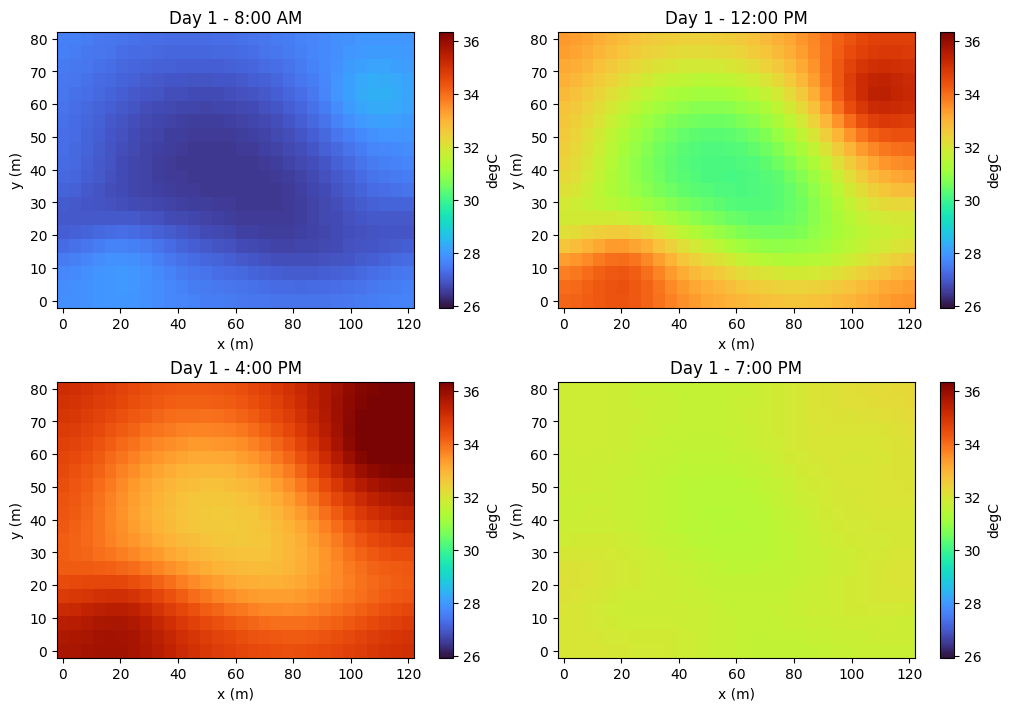

Saved: outputs\truth_day1_selected_hours.png


In [89]:
def hour_to_label(hour):
    suffix = "AM" if hour < 12 else "PM"
    h = int(hour if hour <= 12 else hour - 12)
    return f"{h}:00 {suffix}"


selected_hours = [8.0, 12.0, 16.0, 19.0]
selected_indices = [int(np.argmin(np.abs(sample_hours - h))) for h in selected_hours]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
vmin = np.percentile(truth_fields[:train_days], 1)
vmax = np.percentile(truth_fields[:train_days], 99)
for ax, idx, hour in zip(axes.ravel(), selected_indices, selected_hours):
    im = ax.pcolormesh(X, Y, truth_fields[0, idx], shading="auto", cmap="turbo", vmin=vmin, vmax=vmax)
    ax.set_title(f"Day 1 - {hour_to_label(hour)}")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    fig.colorbar(im, ax=ax, fraction=0.046, label="degC")

snapshot_train_path = OUTPUTS / "truth_day1_selected_hours.png"
fig.savefig(snapshot_train_path, dpi=160)
plt.show()
print(f"Saved: {snapshot_train_path}")

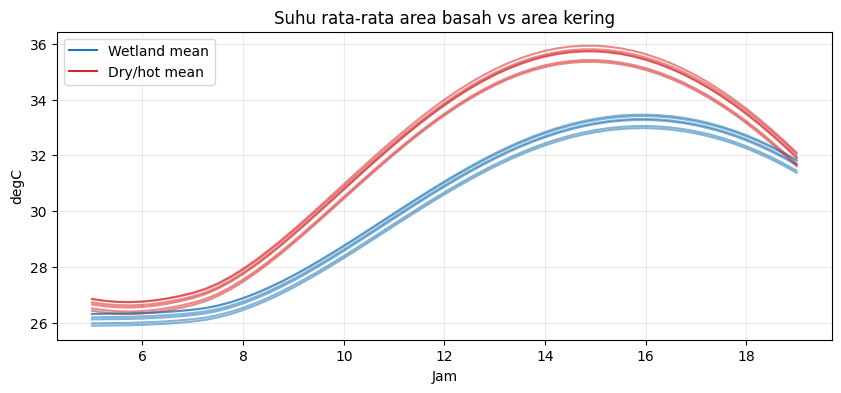

Saved: outputs\wetland_vs_dry_timeseries.png


In [90]:
fig, ax = plt.subplots(figsize=(10, 4))
for day in all_days:
    day_data = summary_df[summary_df["day"] == day]
    ax.plot(day_data["hour"], day_data["mean_wetland_C"], color="tab:blue", alpha=0.55)
    ax.plot(day_data["hour"], day_data["mean_dry_C"], color="tab:red", alpha=0.55)

ax.plot([], [], color="tab:blue", label="Wetland mean")
ax.plot([], [], color="tab:red", label="Dry/hot mean")
ax.set_title("Suhu rata-rata area basah vs area kering")
ax.set_xlabel("Jam")
ax.set_ylabel("degC")
ax.grid(True, alpha=0.25)
ax.legend()

timeseries_path = OUTPUTS / "wetland_vs_dry_timeseries.png"
fig.savefig(timeseries_path, dpi=160)
plt.show()
print(f"Saved: {timeseries_path}")

## 9. Menyiapkan data untuk NN dan PINN

Input model:

- `x_m`, `y_m`: koordinat.
- `t_hours`: jam absolut relatif dari Day 1 jam 5 AM.
- Fitur tambahan seperti jam lokal, radiasi, suhu udara, dan fraksi penutup dihitung di dalam model agar tetap konsisten dengan residual fisika PINN.

Output model:

- suhu `T(x,y,t)` dalam degC.

NN biasa hanya meminimalkan error data. PINN meminimalkan error data plus residual PDE:

```text
residual = T_t - alpha_eff (T_xx + T_yy) - (T_eq - T)/tau
```

In [91]:
x_train_np = train_df["x_m"].to_numpy(np.float32).reshape(-1, 1)
y_train_np = train_df["y_m"].to_numpy(np.float32).reshape(-1, 1)
t_train_np = train_df["t_hours"].to_numpy(np.float32).reshape(-1, 1)
T_train_np = train_df["temperature_observed_C"].to_numpy(np.float32).reshape(-1, 1)

x_test_np = test_df["x_m"].to_numpy(np.float32).reshape(-1, 1)
y_test_np = test_df["y_m"].to_numpy(np.float32).reshape(-1, 1)
t_test_np = test_df["t_hours"].to_numpy(np.float32).reshape(-1, 1)
T_test_np = test_df["temperature_truth_C"].to_numpy(np.float32).reshape(-1, 1)

T_mean = float(T_train_np.mean())
T_std = float(T_train_np.std())
print(f"T_mean train={T_mean:.3f}, T_std train={T_std:.3f}")

x_train_t = torch.tensor(x_train_np, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32, device=device)
t_train_t = torch.tensor(t_train_np, dtype=torch.float32, device=device)
T_train_norm_t = torch.tensor((T_train_np - T_mean) / T_std, dtype=torch.float32, device=device)

print(f"Training samples: {len(x_train_np):,}")
print(f"Test extrapolation samples: {len(x_test_np):,}")

T_mean train=30.833, T_std train=3.121
Training samples: 102,600
Test extrapolation samples: 102,600


In [92]:
class WetlandMLP(nn.Module):
    def __init__(self, y_mean, y_std, width=64, depth=4):
        super().__init__()
        self.y_mean = float(y_mean)
        self.y_std = float(y_std)
        in_dim = 13
        layers = []
        last = in_dim
        for _ in range(depth):
            layers.append(nn.Linear(last, width))
            layers.append(nn.Tanh())
            last = width
        layers.append(nn.Linear(last, 1))
        self.net = nn.Sequential(*layers)

    def features(self, x_m, y_m, t_hours):
        water, vegetation, impervious = spatial_cover_torch(x_m, y_m)
        solar, air, rh, wind, day_number, hour_of_day, phase = weather_forcing_torch(t_hours)
        x_scaled = 2.0 * x_m / Lx - 1.0
        y_scaled = 2.0 * y_m / Ly - 1.0
        hour_scaled = 2.0 * phase - 1.0
        day_scaled = 2.0 * (day_number - 1.0) / max(num_days - 1.0, 1.0) - 1.0
        solar_scaled = solar / PHYS["max_clear_sky_solar_W_m2"]
        air_scaled = (air - 30.0) / 6.0
        rh_scaled = (rh - 70.0) / 20.0
        wind_scaled = (wind - 1.1) / 0.4
        return torch.cat(
            [
                x_scaled,
                y_scaled,
                hour_scaled,
                day_scaled,
                torch.sin(math.pi * phase),
                torch.cos(math.pi * phase),
                solar_scaled,
                air_scaled,
                rh_scaled,
                wind_scaled,
                water,
                vegetation,
                impervious,
            ],
            dim=1,
        )

    def forward_norm(self, x_m, y_m, t_hours):
        return self.net(self.features(x_m, y_m, t_hours))

    def temperature(self, x_m, y_m, t_hours):
        return self.y_mean + self.y_std * self.forward_norm(x_m, y_m, t_hours)


def make_model():
    return WetlandMLP(
        T_mean,
        T_std,
        width=CONFIG["training"]["hidden_width"],
        depth=CONFIG["training"]["hidden_depth"],
    ).to(device)

In [93]:
def train_nn(model):
    cfg = CONFIG["training"]
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["learning_rate"])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(cfg["nn_epochs"] // 3, 1), gamma=0.5)
    history = []
    n = x_train_t.shape[0]
    t0 = time.time()
    for epoch in range(1, cfg["nn_epochs"] + 1):
        idx = torch.randint(0, n, (cfg["batch_size_data"],), device=device)
        pred_norm = model.forward_norm(x_train_t[idx], y_train_t[idx], t_train_t[idx])
        loss = F.mse_loss(pred_norm, T_train_norm_t[idx])

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        scheduler.step()

        if epoch == 1 or epoch % 100 == 0 or epoch == cfg["nn_epochs"]:
            history.append({"epoch": epoch, "data_loss": float(loss.detach().cpu()), "seconds": time.time() - t0})
            print(f"NN epoch {epoch:4d} | data_loss={history[-1]['data_loss']:.5f}")
    return pd.DataFrame(history)


nn_model = make_model()
nn_history = train_nn(nn_model)
display(nn_history.tail())

NN epoch    1 | data_loss=1.02272
NN epoch  100 | data_loss=0.01997
NN epoch  200 | data_loss=0.01210
NN epoch  300 | data_loss=0.00857
NN epoch  400 | data_loss=0.00599
NN epoch  500 | data_loss=0.00576
NN epoch  600 | data_loss=0.00546


,epoch,data_loss,seconds
2,200,0.012096,1.136832
3,300,0.008574,1.642249
4,400,0.005991,2.151804
5,500,0.005763,2.633510
6,600,0.005456,3.085973


## 10. Training PINN

PINN memakai arsitektur yang sama dengan NN, lalu dilatih dengan dua komponen loss:

```text
loss = loss_data + pde_weight * loss_pde
```

`loss_pde` dihitung pada titik kolokasi acak di seluruh domain Day 1 sampai Day 6, tetapi tanpa memakai label suhu Day 4 sampai Day 6. Dengan cara ini, PINN tetap hanya melihat data observasi 3 hari pertama, tetapi diberi tahu bahwa prediksi masa depan harus mematuhi persamaan difusi panas.

In [94]:
def sample_collocation(n):
    day0 = torch.randint(0, num_days, (n, 1), device=device, dtype=torch.int64).float()
    hour_offset = daylight_hours * torch.rand((n, 1), device=device)
    t = day0 * 24.0 + hour_offset
    x = Lx * torch.rand((n, 1), device=device)
    y = Ly * torch.rand((n, 1), device=device)
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    return x, y, t


def pinn_residual(model, x_m, y_m, t_hours):
    T = model.temperature(x_m, y_m, t_hours)
    ones = torch.ones_like(T)

    T_t = torch.autograd.grad(T, t_hours, ones, create_graph=True, retain_graph=True)[0]
    T_x = torch.autograd.grad(T, x_m, ones, create_graph=True, retain_graph=True)[0]
    T_y = torch.autograd.grad(T, y_m, ones, create_graph=True, retain_graph=True)[0]
    T_xx = torch.autograd.grad(T_x, x_m, torch.ones_like(T_x), create_graph=True, retain_graph=True)[0]
    T_yy = torch.autograd.grad(T_y, y_m, torch.ones_like(T_y), create_graph=True, retain_graph=True)[0]

    alpha_h = PHYS["alpha_eff_m2_s"] * 3600.0
    T_eq = equilibrium_temperature_torch(x_m, y_m, t_hours)
    tau_h = tau_hours_torch(x_m, y_m)
    return T_t - alpha_h * (T_xx + T_yy) - (T_eq - T) / tau_h


def train_pinn(model):
    cfg = CONFIG["training"]
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["learning_rate"])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(cfg["pinn_epochs"] // 3, 1), gamma=0.5)
    history = []
    n = x_train_t.shape[0]
    t0 = time.time()

    for epoch in range(1, cfg["pinn_epochs"] + 1):
        idx = torch.randint(0, n, (cfg["batch_size_data"],), device=device)
        pred_norm = model.forward_norm(x_train_t[idx], y_train_t[idx], t_train_t[idx])
        data_loss = F.mse_loss(pred_norm, T_train_norm_t[idx])

        xc, yc, tc = sample_collocation(cfg["batch_size_collocation"])
        residual = pinn_residual(model, xc, yc, tc)
        pde_loss = torch.mean((residual / cfg["residual_scale_C_per_h"]) ** 2)

        loss = data_loss + cfg["pde_weight"] * pde_loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        scheduler.step()

        if epoch == 1 or epoch % 100 == 0 or epoch == cfg["pinn_epochs"]:
            row = {
                "epoch": epoch,
                "data_loss": float(data_loss.detach().cpu()),
                "pde_loss": float(pde_loss.detach().cpu()),
                "total_loss": float(loss.detach().cpu()),
                "seconds": time.time() - t0,
            }
            history.append(row)
            print(
                f"PINN epoch {epoch:4d} | data_loss={row['data_loss']:.5f} "
                f"| pde_loss={row['pde_loss']:.5f} | total={row['total_loss']:.5f}"
            )
    return pd.DataFrame(history)


pinn_model = make_model()
pinn_model.load_state_dict(nn_model.state_dict())
pinn_history = train_pinn(pinn_model)
display(pinn_history.tail())

PINN epoch    1 | data_loss=0.00532 | pde_loss=0.03515 | total=0.01411
PINN epoch  100 | data_loss=0.00491 | pde_loss=0.02097 | total=0.01015
PINN epoch  200 | data_loss=0.00420 | pde_loss=0.01540 | total=0.00805
PINN epoch  300 | data_loss=0.00386 | pde_loss=0.01233 | total=0.00694
PINN epoch  400 | data_loss=0.00343 | pde_loss=0.00942 | total=0.00579
PINN epoch  500 | data_loss=0.00312 | pde_loss=0.00834 | total=0.00520
PINN epoch  600 | data_loss=0.00316 | pde_loss=0.00748 | total=0.00503


,epoch,data_loss,pde_loss,total_loss,seconds
2,200,0.004198,0.015402,0.008048,13.479391
3,300,0.003858,0.012326,0.006940,20.047118
4,400,0.003432,0.009423,0.005788,26.497606
5,500,0.003116,0.008340,0.005201,32.993478
6,600,0.003159,0.007483,0.005030,39.521255


## 11. Prediksi Day 4 sampai Day 6 dan metrik akurasi

Fokus evaluasi adalah ekstrapolasi, yaitu Day 4 sampai Day 6. Metrik:

- RMSE: makin kecil makin baik.
- MAE: error absolut rata-rata.
- R2: makin dekat ke 1 makin baik.
- MaxAbsError: error absolut terburuk.

Perbandingan pada bagian ini hanya dilakukan untuk NN dan PINN.

In [95]:
def predict_model(model, x_np, y_np, t_np, batch_size=32768):
    model.eval()
    preds = []
    with torch.no_grad():
        for start in range(0, len(x_np), batch_size):
            end = start + batch_size
            xb = torch.tensor(x_np[start:end], dtype=torch.float32, device=device)
            yb = torch.tensor(y_np[start:end], dtype=torch.float32, device=device)
            tb = torch.tensor(t_np[start:end], dtype=torch.float32, device=device)
            pred = model.temperature(xb, yb, tb).detach().cpu().numpy()
            preds.append(pred)
    return np.vstack(preds).reshape(-1)


nn_test_pred = predict_model(nn_model, x_test_np, y_test_np, t_test_np)
pinn_test_pred = predict_model(pinn_model, x_test_np, y_test_np, t_test_np)
truth_test = T_test_np.reshape(-1)

eval_df = test_df.copy()
eval_df["pred_nn_C"] = nn_test_pred
eval_df["pred_pinn_C"] = pinn_test_pred

MODEL_COLUMNS = [("NN", "pred_nn_C"), ("PINN", "pred_pinn_C")]


def compute_metrics(y_true, y_pred):
    err = y_pred - y_true
    ss_res = np.sum(err ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return {
        "RMSE_C": np.sqrt(np.mean(err ** 2)),
        "MAE_C": np.mean(np.abs(err)),
        "R2": 1.0 - ss_res / ss_tot,
        "MaxAbsError_C": np.max(np.abs(err)),
        "Bias_C": np.mean(err),
    }


metrics = []
for name, col in MODEL_COLUMNS:
    row = {"model": name}
    row.update(compute_metrics(eval_df["temperature_truth_C"].to_numpy(), eval_df[col].to_numpy()))
    metrics.append(row)
metrics_df = pd.DataFrame(metrics).sort_values("RMSE_C")
display(metrics_df.round(4))

period_rows = []
for (day, period), group in eval_df.groupby(["day", "period"]):
    for name, col in MODEL_COLUMNS:
        row = {"day": day, "period": period, "model": name}
        row.update(compute_metrics(group["temperature_truth_C"].to_numpy(), group[col].to_numpy()))
        period_rows.append(row)
period_metrics_df = pd.DataFrame(period_rows)
display(period_metrics_df.pivot_table(index=["day", "period"], columns="model", values="RMSE_C").round(3))

metrics_path = OUTPUTS / "future_extrapolation_metrics.csv"
period_metrics_path = OUTPUTS / "future_extrapolation_metrics_by_period.csv"
predictions_path = OUTPUTS / "future_predictions_days_4_6.csv"
metrics_df.to_csv(metrics_path, index=False)
period_metrics_df.to_csv(period_metrics_path, index=False)
eval_df.to_csv(predictions_path, index=False)
print(f"Saved: {metrics_path}")
print(f"Saved: {period_metrics_path}")
print(f"Saved: {predictions_path}")

,model,RMSE_C,MAE_C,R2,MaxAbsError_C,Bias_C
1,PINN,0.2817,0.2386,0.9918,0.8230,-0.1344
0,NN,0.4673,0.3980,0.9775,1.4615,-0.3859


model                    NN   PINN
day period                        
4   pagi_5_10         0.490  0.408
    siang_10_15       0.678  0.345
    sore_malam_15_19  0.602  0.355
5   pagi_5_10         0.370  0.249
    siang_10_15       0.537  0.218
    sore_malam_15_19  0.452  0.202
6   pagi_5_10         0.200  0.158
    siang_10_15       0.380  0.254
    sore_malam_15_19  0.299  0.248

Saved: outputs\future_extrapolation_metrics.csv
Saved: outputs\future_extrapolation_metrics_by_period.csv
Saved: outputs\future_predictions_days_4_6.csv


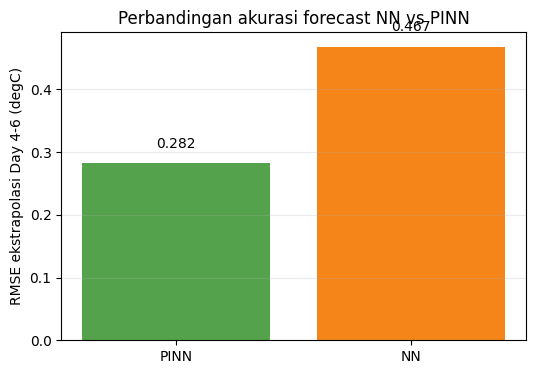

Saved: outputs\rmse_comparison_future.png


In [96]:
fig, ax = plt.subplots(figsize=(6, 4))
order = metrics_df["model"].tolist()
color_map = {"NN": "#f58518", "PINN": "#54a24b"}
ax.bar(order, metrics_df["RMSE_C"], color=[color_map[name] for name in order])
ax.set_ylabel("RMSE ekstrapolasi Day 4-6 (degC)")
ax.set_title("Perbandingan akurasi forecast NN vs PINN")
ax.grid(axis="y", alpha=0.25)
for i, value in enumerate(metrics_df["RMSE_C"]):
    ax.text(i, value + 0.02, f"{value:.3f}", ha="center", va="bottom")

rmse_bar_path = OUTPUTS / "rmse_comparison_future.png"
fig.savefig(rmse_bar_path, dpi=160)
plt.show()
print(f"Saved: {rmse_bar_path}")

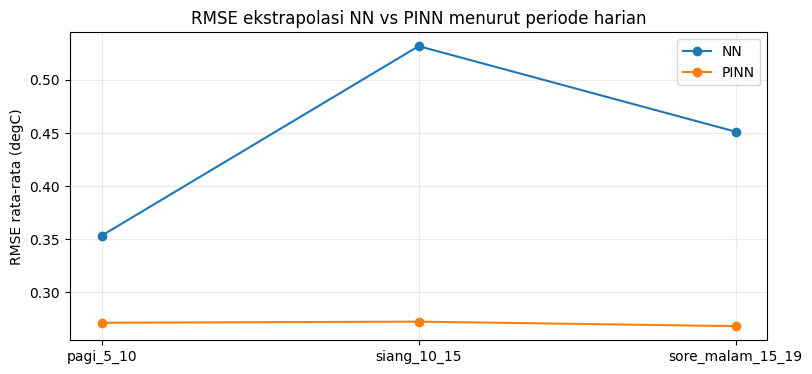

Saved: outputs\rmse_by_period_future.png


In [97]:
fig, ax = plt.subplots(figsize=(9, 4))
period_order = ["pagi_5_10", "siang_10_15", "sore_malam_15_19"]
for model_name, _ in MODEL_COLUMNS:
    subset = period_metrics_df[period_metrics_df["model"] == model_name]
    grouped = subset.groupby("period")["RMSE_C"].mean().reindex(period_order)
    ax.plot(period_order, grouped, marker="o", label=model_name)
ax.set_ylabel("RMSE rata-rata (degC)")
ax.set_title("RMSE ekstrapolasi NN vs PINN menurut periode harian")
ax.grid(True, alpha=0.25)
ax.legend()

period_rmse_path = OUTPUTS / "rmse_by_period_future.png"
fig.savefig(period_rmse_path, dpi=160)
plt.show()
print(f"Saved: {period_rmse_path}")

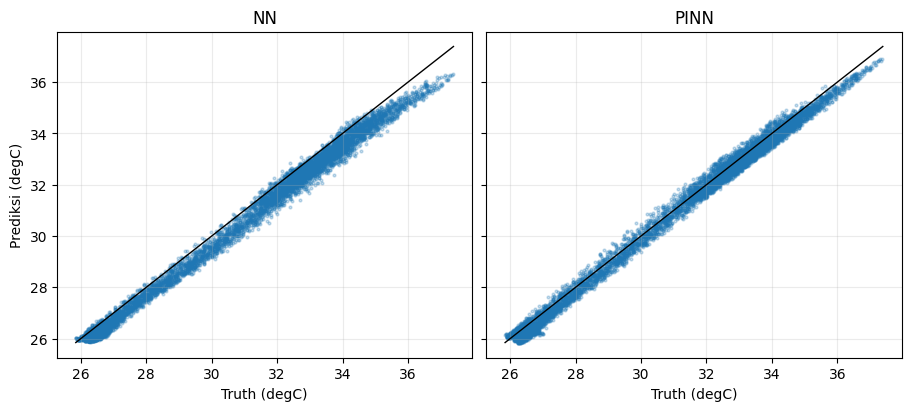

Saved: outputs\predicted_vs_truth_scatter_future.png


In [98]:
rng_plot = np.random.default_rng(seed)
sample_idx = rng_plot.choice(len(eval_df), size=min(7000, len(eval_df)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True, sharex=True, sharey=True)
for ax, (name, col) in zip(axes, MODEL_COLUMNS):
    ax.scatter(
        eval_df["temperature_truth_C"].to_numpy()[sample_idx],
        eval_df[col].to_numpy()[sample_idx],
        s=4,
        alpha=0.25,
    )
    lo = eval_df["temperature_truth_C"].min()
    hi = eval_df["temperature_truth_C"].max()
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Truth (degC)")
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel("Prediksi (degC)")

scatter_path = OUTPUTS / "predicted_vs_truth_scatter_future.png"
fig.savefig(scatter_path, dpi=160)
plt.show()
print(f"Saved: {scatter_path}")

## 12. Plot 2D hasil ekstrapolasi

Plot berikut menampilkan peta suhu Day 4 pada 12 PM untuk ground truth sintetis, NN, dan PINN.

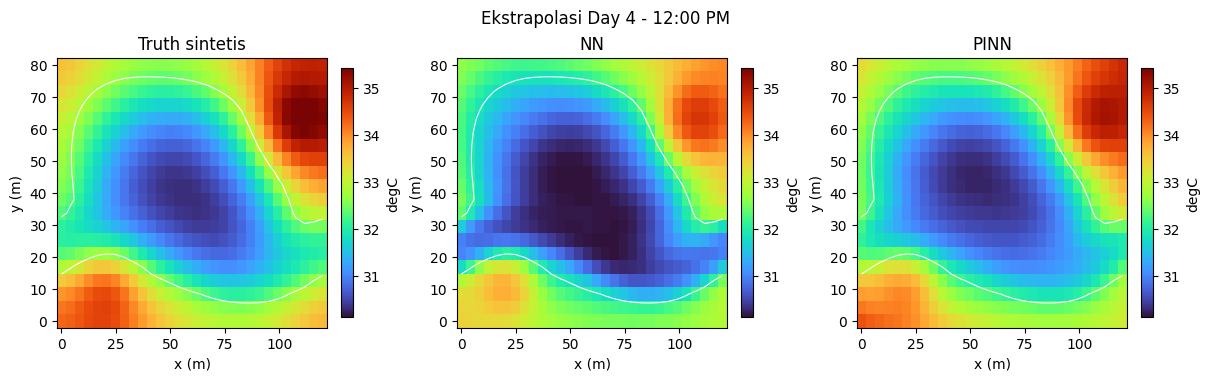

Saved: outputs\snapshot_day4_12pm_models.png


In [99]:
nn_future_fields = nn_test_pred.reshape(forecast_days, len(sample_hours), ny, nx)
pinn_future_fields = pinn_test_pred.reshape(forecast_days, len(sample_hours), ny, nx)
truth_future_fields = truth_fields[train_days:]


def plot_model_snapshot(day, hour, save_path):
    day_index = int(day - (train_days + 1))
    time_index = int(np.argmin(np.abs(sample_hours - hour)))
    fields = [
        ("Truth sintetis", truth_future_fields[day_index, time_index]),
        ("NN", nn_future_fields[day_index, time_index]),
        ("PINN", pinn_future_fields[day_index, time_index]),
    ]
    vmin = min(np.percentile(arr, 1) for _, arr in fields)
    vmax = max(np.percentile(arr, 99) for _, arr in fields)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), constrained_layout=True)
    for ax, (title, arr) in zip(axes, fields):
        im = ax.pcolormesh(X, Y, arr, shading="auto", cmap="turbo", vmin=vmin, vmax=vmax)
        ax.contour(X, Y, WATER + 0.7 * VEGETATION, levels=[0.55], colors="white", linewidths=0.8)
        ax.set_title(title)
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        fig.colorbar(im, ax=ax, fraction=0.046, label="degC")
    fig.suptitle(f"Ekstrapolasi Day {day} - {hour_to_label(hour)}")
    fig.savefig(save_path, dpi=160)
    plt.show()
    print(f"Saved: {save_path}")


snapshot_future_path = OUTPUTS / "snapshot_day4_12pm_models.png"
plot_model_snapshot(day=4, hour=12.0, save_path=snapshot_future_path)

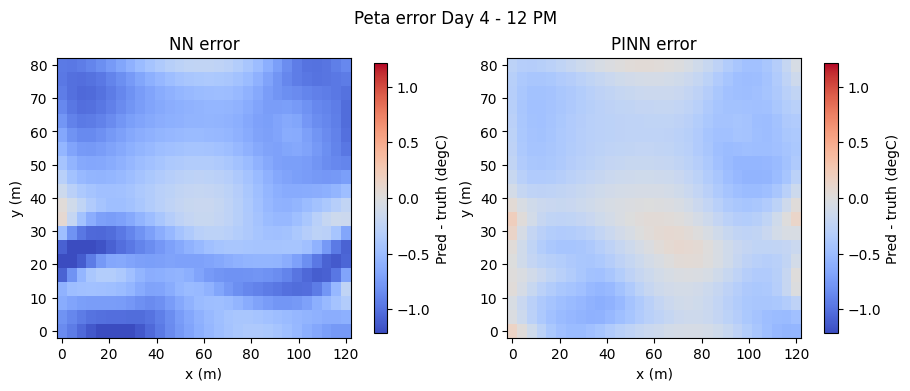

Saved: outputs\error_map_day4_12pm.png


In [100]:
time_12pm_index = int(np.argmin(np.abs(sample_hours - 12.0)))
error_fields = [
    ("NN error", nn_future_fields[0, time_12pm_index] - truth_future_fields[0, time_12pm_index]),
    ("PINN error", pinn_future_fields[0, time_12pm_index] - truth_future_fields[0, time_12pm_index]),
]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), constrained_layout=True)
err_lim = max(abs(np.percentile(arr, 1)) for _, arr in error_fields)
err_lim = max(err_lim, max(abs(np.percentile(arr, 99)) for _, arr in error_fields))
for ax, (title, arr) in zip(axes, error_fields):
    im = ax.pcolormesh(X, Y, arr, shading="auto", cmap="coolwarm", vmin=-err_lim, vmax=err_lim)
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    fig.colorbar(im, ax=ax, fraction=0.046, label="Pred - truth (degC)")
fig.suptitle("Peta error Day 4 - 12 PM")

error_map_path = OUTPUTS / "error_map_day4_12pm.png"
fig.savefig(error_map_path, dpi=160)
plt.show()
print(f"Saved: {error_map_path}")

## 13. GIF animasi suhu Day 4 sampai Day 6

GIF dibuat dari plot 2D per jam. Setiap frame berisi:

- ground truth sintetis,
- NN,
- PINN.

Kontur putih menunjukkan area dengan indeks lahan basah tinggi (`water + 0.7 vegetation > 0.55`). GIF disimpan dengan loop tak terbatas, sehingga setelah Day 6 selesai animasi kembali ke Day 4.

In [101]:
def make_animation_gif(gif_path, frame_duration_s=0.9):
    frames = []
    hourly_values = np.arange(int(start_hour), int(end_hour) + 1, 1)
    global_vmin = np.percentile(truth_future_fields, 1)
    global_vmax = np.percentile(truth_future_fields, 99)

    for day in future_days:
        day_index = int(day - (train_days + 1))
        for hour in hourly_values:
            time_index = int(np.argmin(np.abs(sample_hours - float(hour))))
            fields = [
                ("Truth", truth_future_fields[day_index, time_index]),
                ("NN", nn_future_fields[day_index, time_index]),
                ("PINN", pinn_future_fields[day_index, time_index]),
            ]

            fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.8), dpi=110, constrained_layout=True)
            for ax, (title, arr) in zip(axes, fields):
                im = ax.pcolormesh(X, Y, arr, shading="auto", cmap="turbo", vmin=global_vmin, vmax=global_vmax)
                ax.contour(X, Y, WATER + 0.7 * VEGETATION, levels=[0.55], colors="white", linewidths=0.7)
                ax.set_title(title, fontsize=10)
                ax.set_xlabel("x (m)", fontsize=8)
                ax.set_ylabel("y (m)", fontsize=8)
                ax.tick_params(labelsize=7)
            fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.78, label="degC")
            fig.suptitle(f"Forecast Day {int(day)} - {hour_to_label(float(hour))}", fontsize=13)
            fig.canvas.draw()
            frame = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
            frames.append(frame)
            plt.close(fig)

    imageio.mimsave(gif_path, frames, duration=frame_duration_s, loop=0)
    return gif_path


gif_path = OUTPUTS / "wetland_buffer_future_animation.gif"
make_animation_gif(gif_path, frame_duration_s=0.9)
print(f"Saved GIF: {gif_path}")

Saved GIF: outputs\wetland_buffer_future_animation.gif


## 14. Cara membaca hasil

1. Jika PINN lebih baik daripada NN pada Day 4 sampai Day 6, artinya regularisasi fisika membantu ekstrapolasi saat data label hanya tersedia pada Day 1 sampai Day 3.
2. Jika NN mendekati PINN, biasanya karena cuaca cerah berulang dan fitur forcing sangat informatif. Pada data nyata yang lebih bising atau kondisi cuaca berubah, perbedaan biasanya lebih terlihat.
3. Error sore/malam bisa berbeda dari siang karena efek inersia termal air dan tanah jenuh lebih kuat saat radiasi turun.

Untuk memakai data lapangan nyata, ganti:

- `weather_forcing_numpy/torch` dengan data radiasi, suhu udara, RH, dan angin aktual.
- `spatial_cover_numpy/torch` dengan peta land cover, NDVI, water index, atau klasifikasi citra.
- `initial_temperature_numpy` dengan pengukuran jam 5 AM.
- `truth_fields` dengan data sensor/grid hasil interpolasi.
- parameter `alpha_eff`, `tau`, dan komponen `T_eq` melalui kalibrasi.

In [102]:
print("Output utama:")
for path in [
    train_csv,
    benchmark_csv,
    summary_csv,
    metrics_path,
    period_metrics_path,
    predictions_path,
    landcover_path,
    forcing_path,
    snapshot_train_path,
    timeseries_path,
    rmse_bar_path,
    period_rmse_path,
    scatter_path,
    snapshot_future_path,
    error_map_path,
    gif_path,
]:
    print("-", path)

print("\nMetrik final ekstrapolasi Day 4-6:")
display(metrics_df.round(4))

Output utama:
- sample\dummy_observations_train_days_1_3.csv
- sample\dummy_truth_benchmark_days_1_6.csv
- sample\daily_period_buffer_summary.csv
- outputs\future_extrapolation_metrics.csv
- outputs\future_extrapolation_metrics_by_period.csv
- outputs\future_predictions_days_4_6.csv
- outputs\landcover_fraction_maps.png
- outputs\clear_sky_forcing.png
- outputs\truth_day1_selected_hours.png
- outputs\wetland_vs_dry_timeseries.png
- outputs\rmse_comparison_future.png
- outputs\rmse_by_period_future.png
- outputs\predicted_vs_truth_scatter_future.png
- outputs\snapshot_day4_12pm_models.png
- outputs\error_map_day4_12pm.png
- outputs\wetland_buffer_future_animation.gif

Metrik final ekstrapolasi Day 4-6:


,model,RMSE_C,MAE_C,R2,MaxAbsError_C,Bias_C
1,PINN,0.2817,0.2386,0.9918,0.8230,-0.1344
0,NN,0.4673,0.3980,0.9775,1.4615,-0.3859
